# Closed channels and thresholds: α + ¹²C

A **closed channel** is one whose threshold lies above the beam energy. It cannot carry
outgoing flux, but it still lives in the coupled Hamiltonian and distorts the scattering
solution from the inside. As the energy crosses a threshold, the channel opens and its
outgoing amplitude switches on — leaving visible structure in the elastic channel.

This notebook scans α + ¹²C scattering (preset `lm.models.ALPHA_C12_ROTOR_MODEL`,
$J = 3$: the ¹²C $2^+$ state at 4.44 MeV and $4^+$ at 14.08 MeV, eight coupled channels)
across both thresholds and watches the channels open.

In [1]:
from __future__ import annotations

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

import lax as lm

model = lm.models.ALPHA_C12_ROTOR_MODEL
channels = lm.models.channels_from_rotor_model(model)
thresholds = sorted({channel.threshold for channel in model.channels if channel.threshold > 0})
for index, channel in enumerate(model.channels):
    print(f"channel {index}: {channel.label:>8}   threshold = {channel.threshold} MeV")

channel 0:  0+, L=3   threshold = 0.0 MeV
channel 1:  2+, L=1   threshold = 4.44 MeV
channel 2:  2+, L=3   threshold = 4.44 MeV
channel 3:  2+, L=5   threshold = 4.44 MeV
channel 4:  4+, L=1   threshold = 14.08 MeV
channel 5:  4+, L=3   threshold = 14.08 MeV
channel 6:  4+, L=5   threshold = 14.08 MeV
channel 7:  4+, L=7   threshold = 14.08 MeV


## Compile once across the thresholds

The energy grid deliberately straddles both excitation thresholds. At compile time `lax`
evaluates **Coulomb Hankel functions for open channels and Whittaker functions for closed
channels** at every (energy, channel) pair — the `is_open` mask in `solver.boundary`
routes each channel to the right matching condition, and
`solver.smatrix_direct` folds the closed channels into the open-channel $S$ matrix
automatically.

In [2]:
energies = jnp.linspace(2.0, 20.0, 60)

solver = lm.compile(
    mesh=lm.MeshSpec("legendre", "x", n=20, scale=11.0, extras={"n_intervals": 4}),
    channels=channels,
    operators=("T+L", "1/r^2"),
    solvers=("rmatrix_direct",),
    energies=energies,
    method="linear_solve",
    V_is_complex=True,
    z1z2=(model.projectile_charge, model.target_charge),
)
interaction = lm.models.interaction_from_rotor_model(model, solver)
smatrices = np.asarray(solver.smatrix_direct(interaction))  # (N_E, N_c, N_c)
open_count = np.asarray(solver.boundary.is_open.sum(axis=1))
print("open channels along the grid:", open_count)

open channels along the grid: [1 1 1 1 1 1 1 1 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4 4
 4 4 4 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8 8]


## Watching channels open

Each inelastic amplitude $|S_{0c}(E)|$ is identically zero while its channel is closed and
switches on at its threshold (dashed lines). The elastic amplitude $|S_{00}|$ responds at
each opening — newly available flux is taken from the entrance channel. The markers on
the elastic curve are published benchmark values (Descouvemont, *CPC* **200** (2016)).

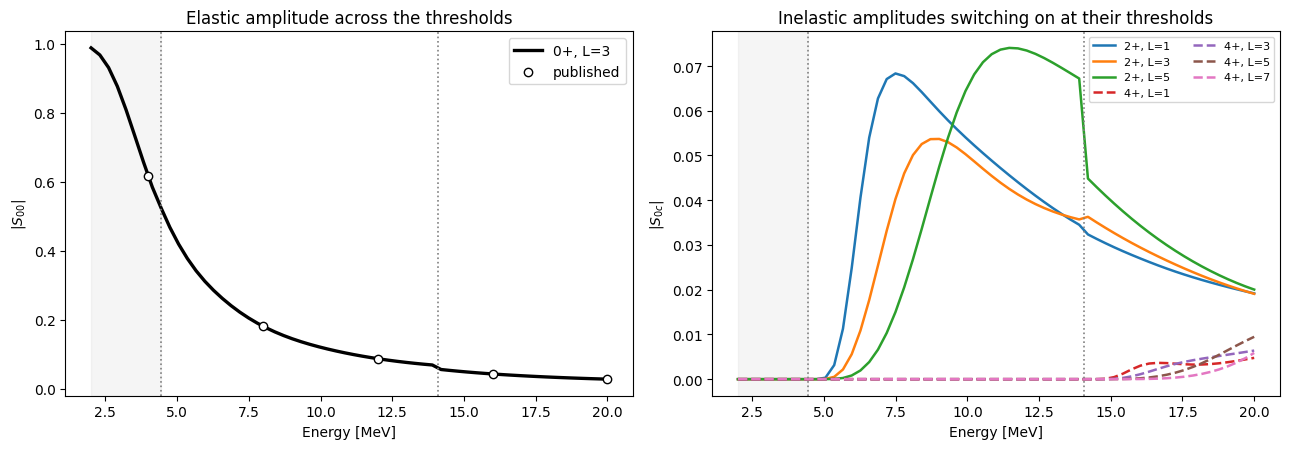

In [3]:
entrance = np.abs(smatrices[:, :, 0])  # (N_E, N_c)
e_np = np.asarray(energies)

# Published elastic |S_00| checkpoints (Descouvemont, CPC 200 (2016), a = 11 fm grid).
ref_energies = [4.0, 8.0, 12.0, 16.0, 20.0]
ref_elastic = [0.61525, 0.18113, 0.08731, 0.043124, 0.028037]

fig, axes = plt.subplots(1, 2, figsize=(13.0, 4.6))

axes[0].plot(e_np, entrance[:, 0], linewidth=2.4, color="black", label=model.channels[0].label)
axes[0].scatter(ref_energies, ref_elastic, zorder=5, color="white", edgecolor="black", label="published")
axes[0].set_ylabel(r"$|S_{00}|$")
axes[0].set_title("Elastic amplitude across the thresholds")

styles = {4.44: "-", 14.08: "--"}
for index, channel in enumerate(model.channels):
    if channel.threshold == 0.0:
        continue
    axes[1].plot(
        e_np,
        entrance[:, index],
        styles[channel.threshold],
        linewidth=1.8,
        label=channel.label,
    )
axes[1].set_ylabel(r"$|S_{0c}|$")
axes[1].set_title("Inelastic amplitudes switching on at their thresholds")
axes[1].legend(fontsize=8, ncol=2)

for axis in axes:
    for threshold in thresholds:
        axis.axvline(threshold, color="gray", linestyle=":", linewidth=1.2)
    axis.axvspan(e_np[0], thresholds[0], color="gray", alpha=0.08)
    axis.set_xlabel("Energy [MeV]")
axes[0].legend()
fig.tight_layout()

## What you are seeing

- **Below 4.44 MeV** (shaded) only the elastic channel is open: every inelastic amplitude
  is exactly zero, yet the closed $2^+$ channels still shape the elastic solution because
  they are part of the Hamiltonian — their influence enters through the exponentially
  decaying Whittaker boundary condition.
- **At each threshold** the corresponding amplitudes turn on continuously from zero, and
  the elastic channel pays for the new flux.
- The strong overall fall of $|S_{00}|$ with energy is the imaginary optical potential
  absorbing flux into channels the model does not treat explicitly.

The same machinery scales to any channel layout: change the preset's `channels` tuple and
thresholds, and the open/closed bookkeeping follows automatically.